In [1]:
import json
import os
import time
import ipyparallel as ipp

import matplotlib.pyplot as plt
import torch
import train_cluster_cifar_dfca_tf as DFCA
import train_cluster_cifar_tf as IFCA

import numpy as np
import random

from util import *

2025-06-20 23:04:50.587777: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750453490.606684 1322296 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750453490.612573 1322296 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750453490.626586 1322296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750453490.626620 1322296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750453490.626622 1322296 computation_placer.cc:177] computation placer alr

Instructions for updating:
non-resource variables are not supported in the long term


Reads Config file and prepares the arguments you can choose in the config_dfca.json/config_ifca.json

In [2]:
# theoretically irrelevant here because we initialize the model seed randomly (see find_good_initializer())
random.seed(42)
seeds = random.sample(range(10000), 5)
p_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

dfca_gi = []
ifca = []

Running the dfca-gi experiment

In [3]:
import train_cluster_cifar_dfca_tf as DFCA
import json
import time
import torch
import numpy as np


with open("config_pn.json", "r") as read_file:
    config = json.load(read_file)

for pr in p_rates:
    res_final = []
    config['participation_rate'] = pr

    for seed in seeds:
        print(f"---------------------------------DFCA-GI, Participation Rate: {pr}, seed: {seed}---------------------------------")
        start_time = time.time()
        config['data_seed'] = seed
        config['train_seed'] = config['data_seed']

        print("config:",config)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")

        exp = DFCA.TrainCIFARCluster(config)
        exp.setup()
        res = exp.run()
        res_final.append([[r['test']['loss'] for r in res], [r['test']['acc'] for r in res], [r['test']['cl_acc'] for r in res], [r['train']['loss'] for r in res]])
        del exp
        duration = (time.time() - start_time)
        print("---train cluster Ended in %0.2f hour (%.3f sec) " % (duration/float(3600), duration))

    res_mean = np.mean(res_final, axis=0).tolist()
    dfca_gi.append(res_mean)



---------------------------------DFCA-GI, Participation Rate: 0.1, seed: 1824---------------------------------
config: {'m': 200, 'm_test': 40, 'p': 2, 'n': 500, 'participation_rate': 0.1, 'num_epochs': 30, 'batch_size': 50, 'tau': 5, 'lr': 0.25, 'data_seed': 1824, 'train_seed': 1824, 'project_dir': 'output'}
Using device: cuda


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


I0000 00:00:1750453500.986464 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37004 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:01:00.0, compute capability: 8.0
I0000 00:00:1750453500.988398 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 33566 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1750453500.989902 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 37302 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:81:00.0, compute capability: 8.0
I0000 00:00:1750453500.992087 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 20384 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0
I0000 00:00:1750453501.025531 1322296 mlir_graph_optimization_pa

finding good initializer from train data


2025-06-20 23:05:01.442213: W tensorflow/c/c_api.cc:305] Operation '{name:'softmax_linear/biases/Assign' id:221 op device:{requested: '/device:CPU:0', assigned: ''} def:{{{node softmax_linear/biases/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@softmax_linear/biases"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true, _device="/device:CPU:0"](softmax_linear/biases, softmax_linear/biases/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


...

Epoch 27 tst: l 2.057 a 0.548  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000 2.137sec


Epoch 28 tr: l 2.101 a 0.517  clct[np.int64(49), np.int64(51)] ans[np.int64(49), np.int64(51)] lr 0.188680 cl_acc 1.000 44.007sec(train) 4.943sec(infer)


Epoch 28 tst: l 2.020 a 0.552  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000 1.778sec


Epoch 29 tr: l 2.082 a 0.516  clct[np.int64(53), np.int64(47)] ans[np.int64(53), np.int64(47)] lr 0.186793 cl_acc 1.000 45.507sec(train) 4.292sec(infer)


Epoch 29 tst: l 1.976 a 0.557  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000 1.606sec
result written at output/results.pickle
---train cluster Ended in 0.43 hour (1554.248 sec) 


Running the ifca experiment

In [4]:
import train_cluster_cifar_tf as IFCA
import json
import time
import torch
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()


with open("config_pn.json", "r") as read_file:
    config = json.load(read_file)

for pr in p_rates:
    res_final = []
    config['participation_rate'] = pr

    for seed in seeds:
        tf.reset_default_graph()
        print(f"---------------------------------IFCA, Participation Rate: {pr}, seed: {seed}---------------------------------")
        start_time = time.time()
        config['data_seed'] = seed
        config['train_seed'] = config['data_seed']

        print("config:",config)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")

        exp = IFCA.TrainCIFARCluster(config)
        exp.setup()
        res = exp.run()
        res_final.append([[r['test']['loss'] for r in res], [r['test']['acc'] for r in res], [r['test']['cl_acc'] for r in res], [r['train']['loss'] for r in res]])
        del exp
        duration = (time.time() - start_time)
        print("---train cluster Ended in %0.2f hour (%.3f sec) " % (duration/float(3600), duration))

    res_mean = np.mean(res_final, axis=0).tolist()
    ifca.append(res_mean)



---------------------------------IFCA, Participation Rate: 0.1, seed: 1824---------------------------------
config: {'m': 200, 'm_test': 40, 'p': 2, 'n': 500, 'participation_rate': 0.1, 'num_epochs': 30, 'batch_size': 50, 'tau': 5, 'lr': 0.25, 'data_seed': 1824, 'train_seed': 1824, 'project_dir': 'output'}
Using device: cuda


I0000 00:00:1750475227.684170 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37004 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:01:00.0, compute capability: 8.0
I0000 00:00:1750475227.685562 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 33566 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1750475227.686529 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 37302 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:81:00.0, compute capability: 8.0
I0000 00:00:1750475227.688032 1322296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 20384 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0
2025-06-21 05:07:07.762310: W tensorflow/c/c_api.cc:305] Operati

finding good initializer from train data


Epoch -1 tr: l 4.677 a 0.095  clct[np.int64(0), np.int64(20)] ans[np.int64(12), np.int64(8)] cl_acc 0.600000 2.444sec


2025-06-21 05:07:10.256831: W tensorflow/c/c_api.cc:305] Operation '{name:'softmax_linear/biases/Assign' id:221 op device:{requested: '/device:CPU:0', assigned: ''} def:{{{node softmax_linear/biases/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@softmax_linear/biases"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true, _device="/device:CPU:0"](softmax_linear/biases, softmax_linear/biases/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


...

Epoch 27 tst: l 1.279 a 0.669  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000000 1.339sec


Epoch 28 tr: l 1.352 a 0.635  clct[np.int64(53), np.int64(47)] ans[np.int64(47), np.int64(53)] lr 0.188680 cl_acc 1.000000 57.805sec(train) 8.405sec(infer)


Epoch 28 tst: l 1.253 a 0.672  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000000 2.772sec


Epoch 29 tr: l 1.329 a 0.641  clct[np.int64(46), np.int64(54)] ans[np.int64(54), np.int64(46)] lr 0.186793 cl_acc 1.000000 62.911sec(train) 7.147sec(infer)


Epoch 29 tst: l 1.226 a 0.681  clct[np.int64(20), np.int64(20)] ans[np.int64(20), np.int64(20)] cl_acc 1.000000 2.742sec
result written at output/results.pickle
---train cluster Ended in 0.59 hour (2135.962 sec) 


## Plots

DFCA-GI Test Acc:  [[0.10856000000000002, 0.11385, 0.11915, 0.12429000000000001, 0.13376, 0.13969, 0.14539, 0.15448, 0.16323, 0.16958, 0.17463, 0.18186999999999998, 0.18808000000000002, 0.19793, 0.20286999999999997, 0.21280000000000002, 0.21796, 0.22356000000000004, 0.22687, 0.23062, 0.2383, 0.24445999999999998, 0.25238, 0.25882, 0.26580000000000004, 0.26896, 0.27293, 0.27874, 0.28468, 0.28976999999999997, 0.29169999999999996], [0.10527, 0.11982000000000001, 0.13208, 0.14354, 0.15758, 0.17475, 0.18861, 0.20949999999999996, 0.22109, 0.24015, 0.25243000000000004, 0.2589, 0.26637, 0.27787, 0.28774, 0.29579, 0.30504, 0.31270999999999993, 0.32125000000000004, 0.32937000000000005, 0.33687999999999996, 0.34533, 0.35004, 0.35545, 0.35945, 0.36553, 0.36974999999999997, 0.37273, 0.37773, 0.38429, 0.39030000000000004], [0.10442, 0.12935, 0.15661999999999998, 0.17592, 0.19919, 0.22555, 0.24220999999999998, 0.26389, 0.27960999999999997, 0.29256, 0.30513999999999997, 0.31987, 0.33247, 0.34447, 0.347

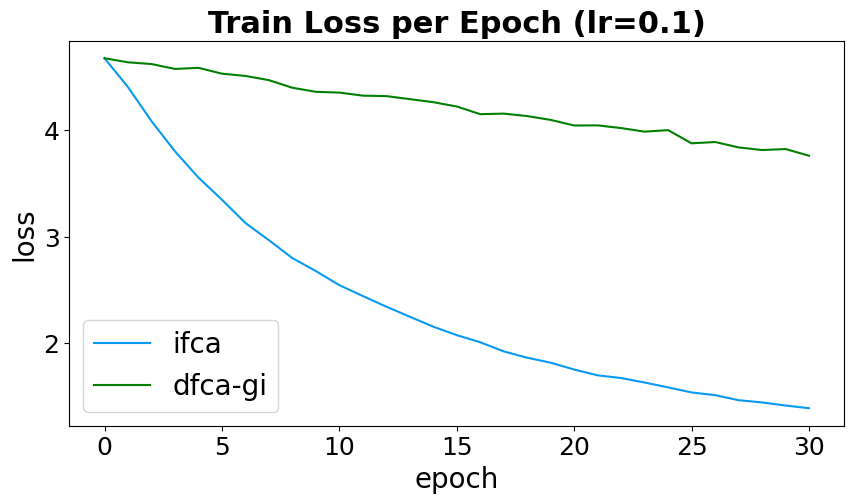

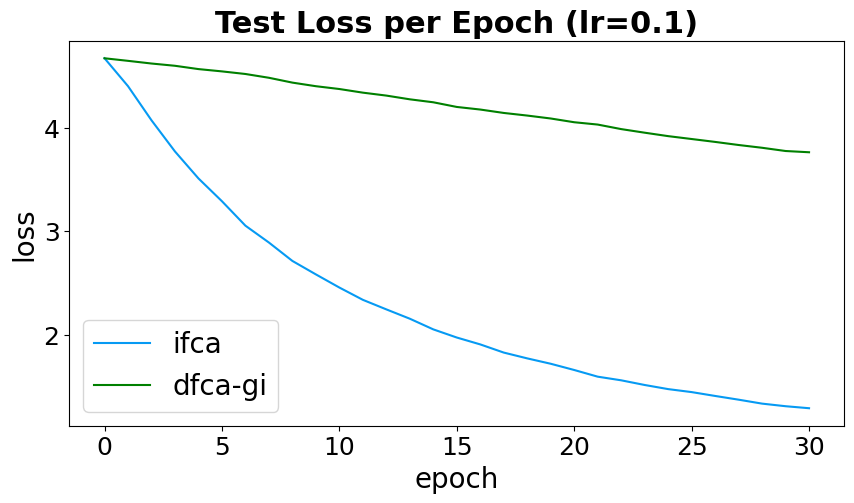

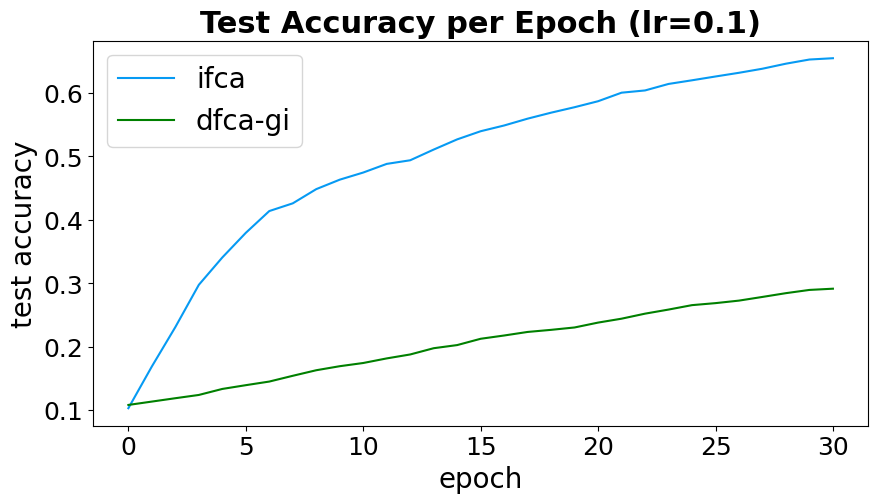

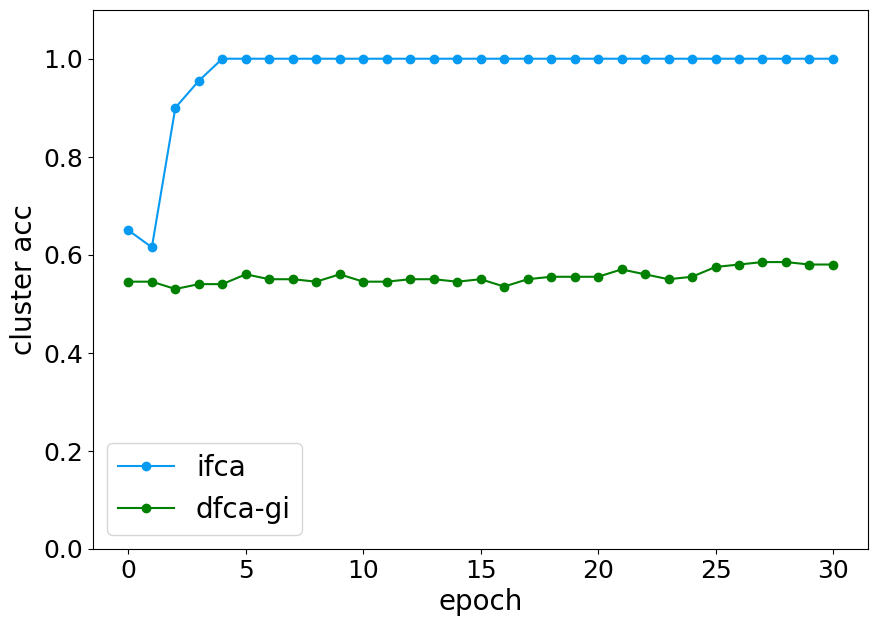

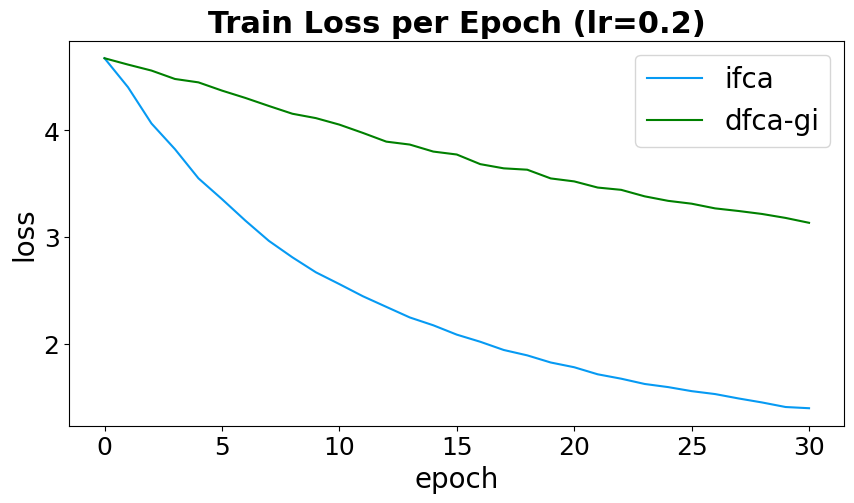

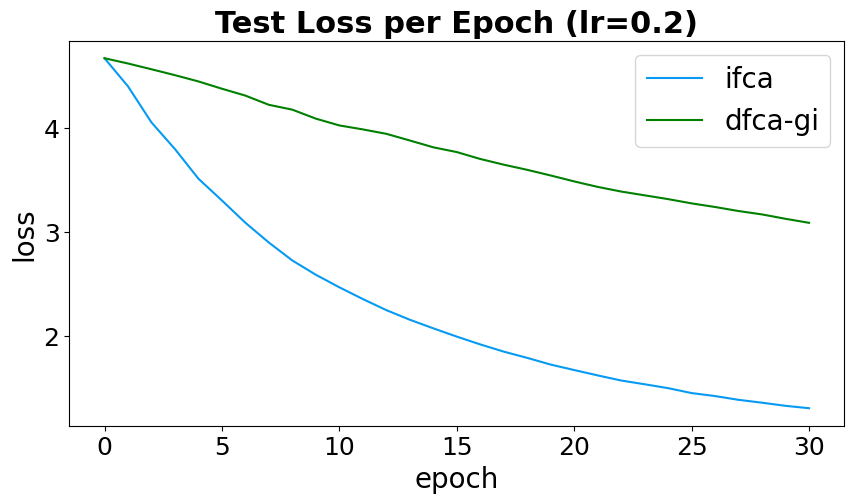

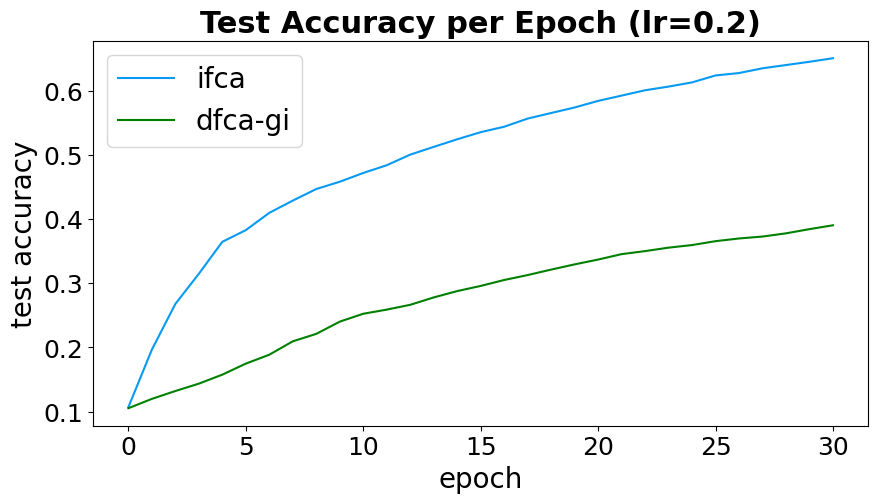

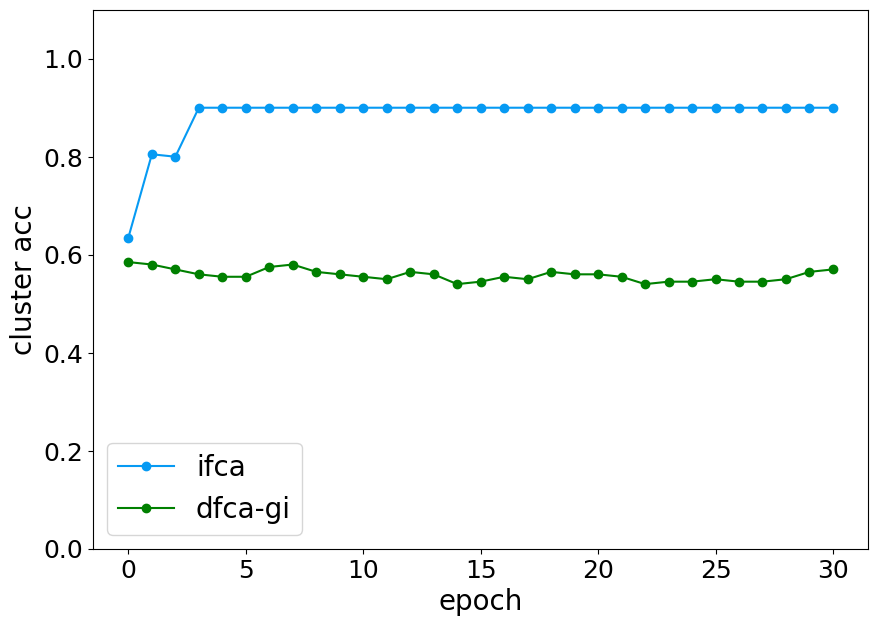

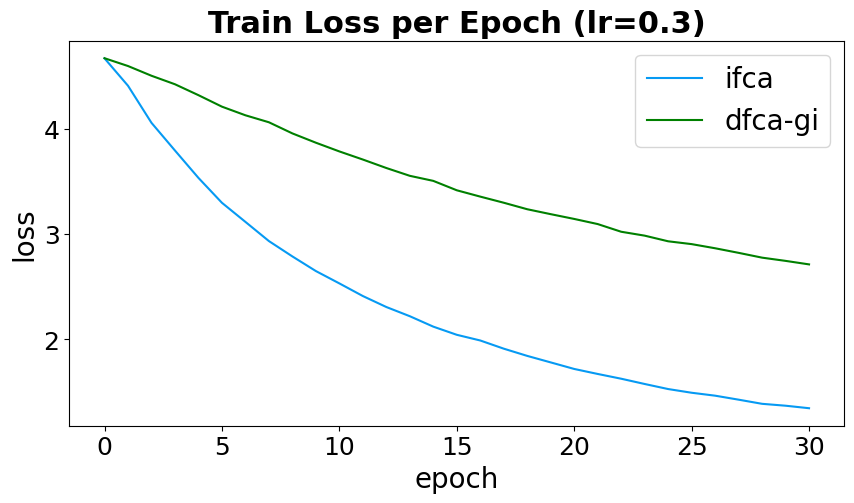

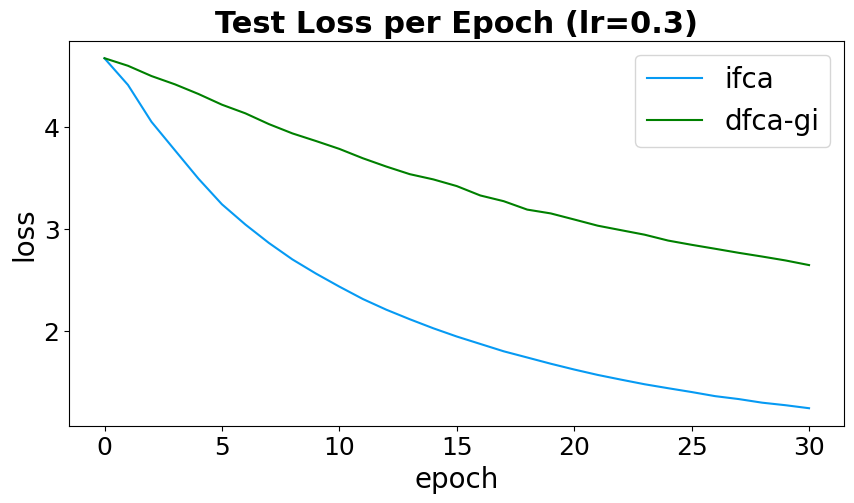

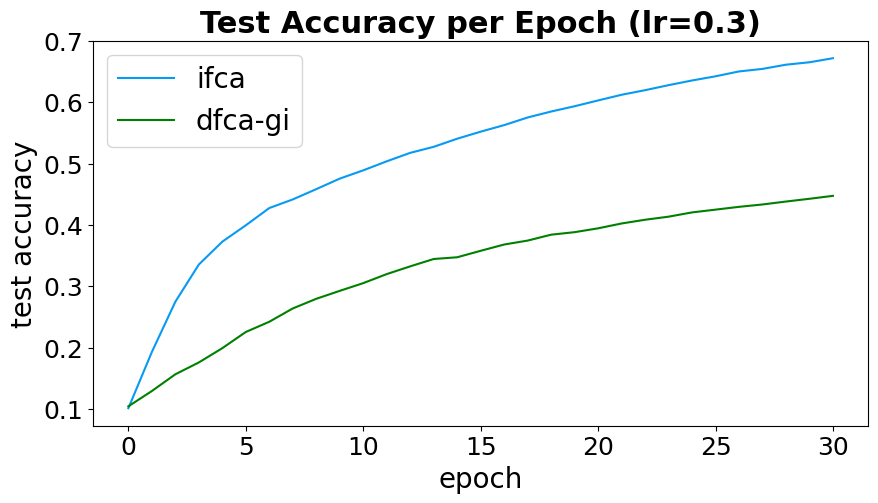

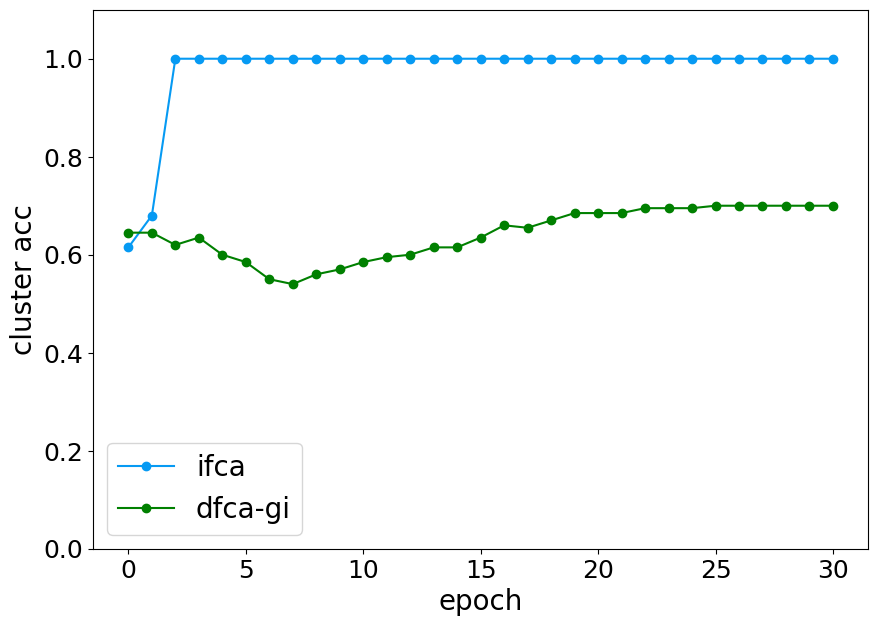

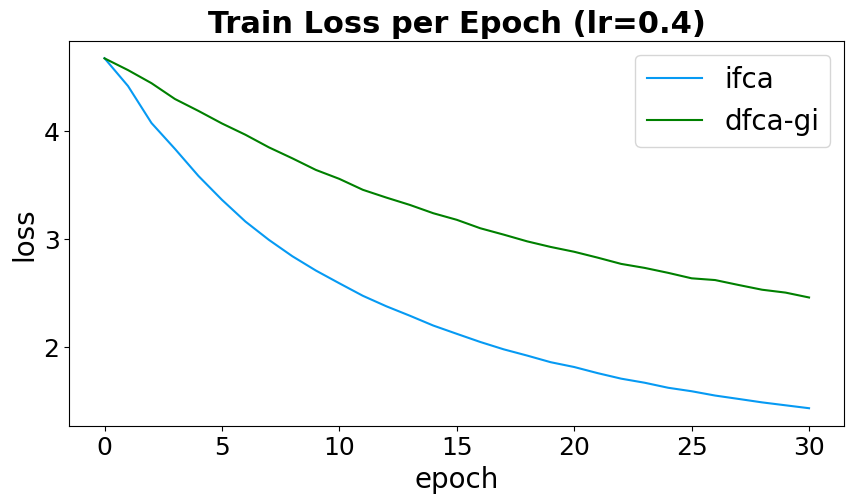

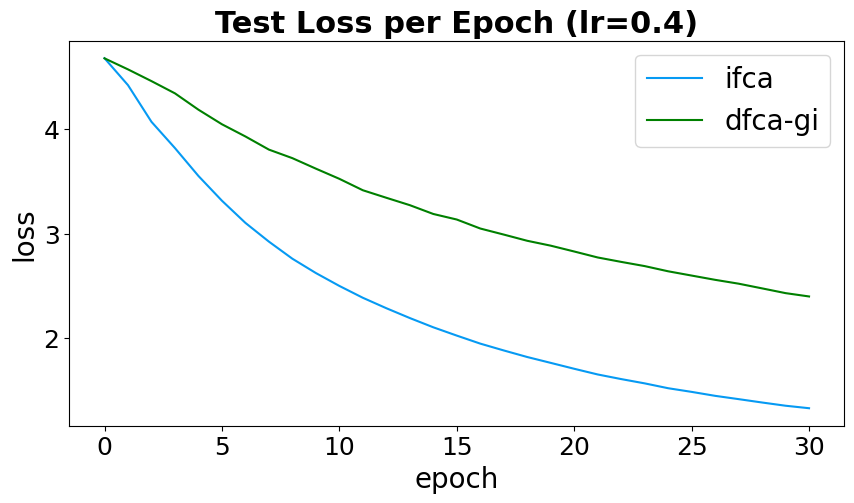

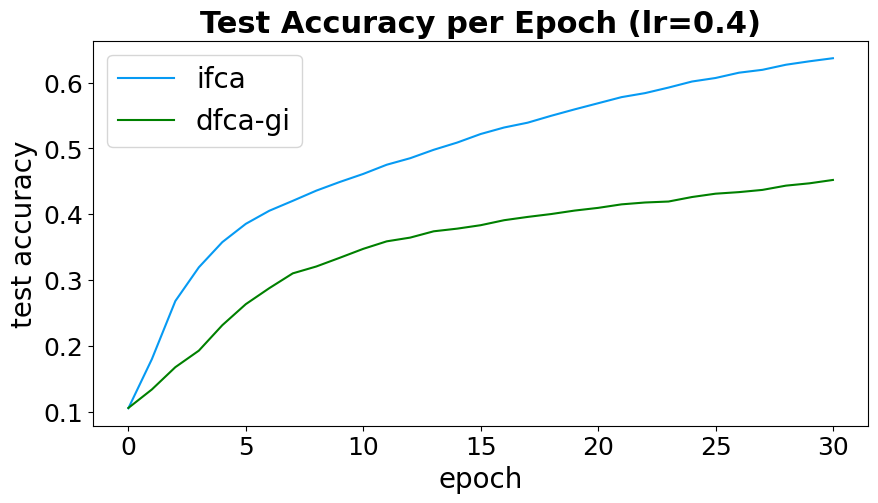

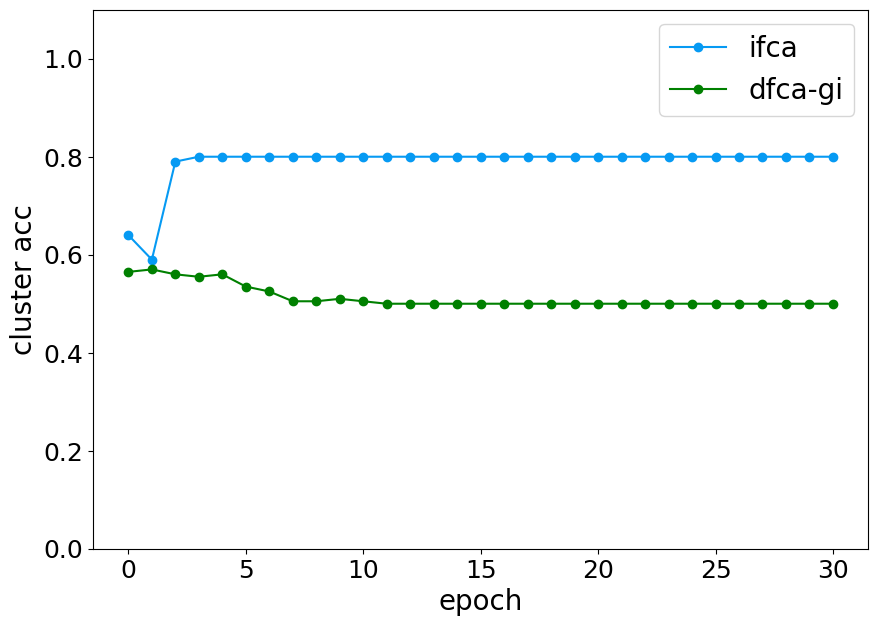

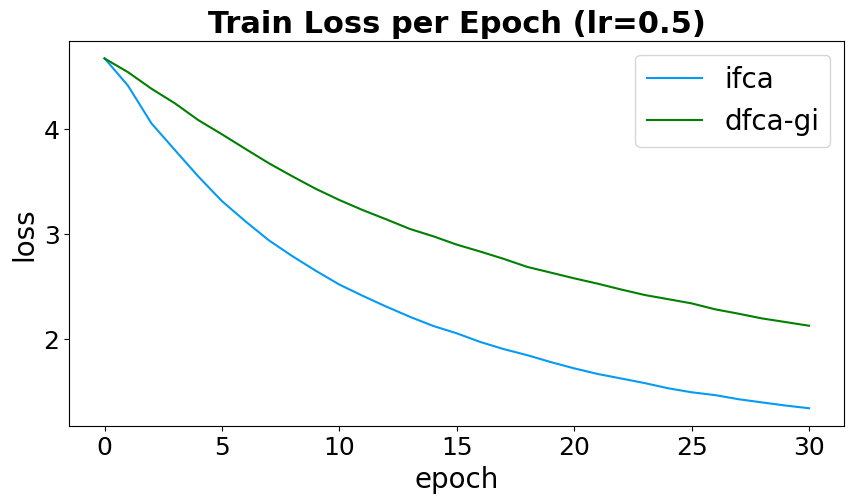

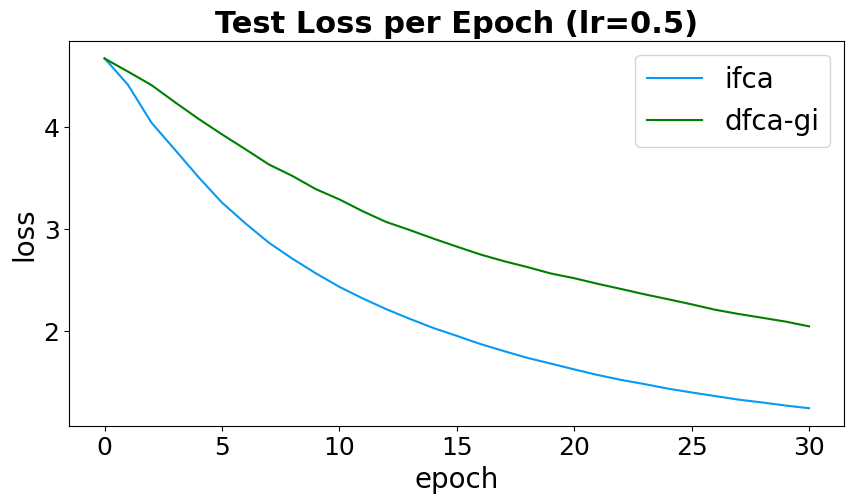

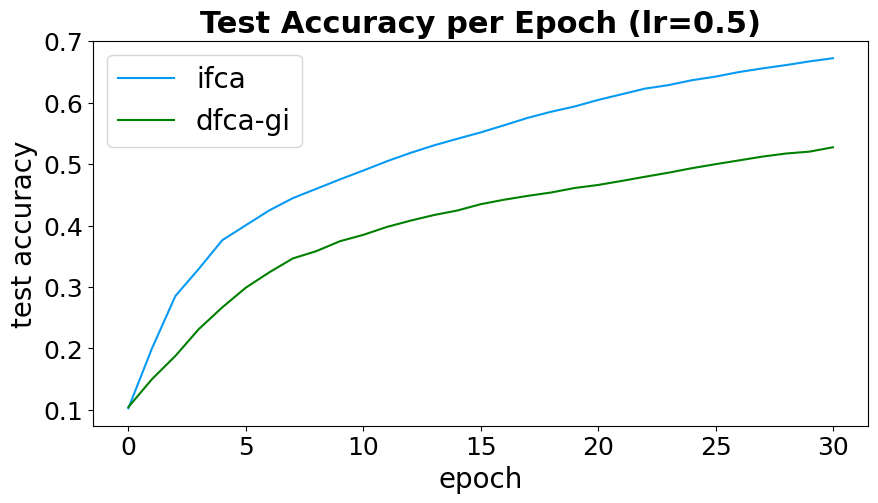

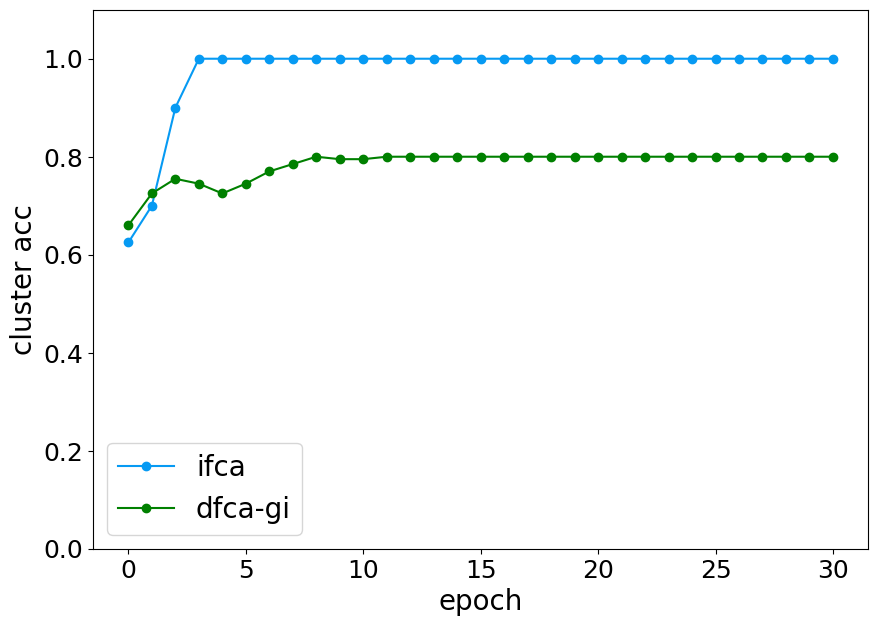

In [5]:

r_ifca = {}
r_dfca_gi = {}

# print("IFCA Test Acc: ", ifca)
# print("DFCA-GI Test Acc: ", dfca_gi)

r_ifca['test_loss'] = []
r_ifca['test_acc'] = []
r_ifca['cl_acc'] = []
r_ifca['train_loss'] = []
for i in range(len(p_rates)):
    r_ifca['test_loss'].append(ifca[i][0])
    r_ifca['test_acc'].append(ifca[i][1])
    r_ifca['cl_acc'].append(ifca[i][2])
    r_ifca['train_loss'].append(ifca[i][3])

r_dfca_gi['test_loss'] = []
r_dfca_gi['test_acc'] = []
r_dfca_gi['cl_acc'] = []
r_dfca_gi['train_loss'] = []
for i in range(len(p_rates)):
    r_dfca_gi['test_loss'].append(dfca_gi[i][0])
    r_dfca_gi['test_acc'].append(dfca_gi[i][1])
    r_dfca_gi['cl_acc'].append(dfca_gi[i][2])
    r_dfca_gi['train_loss'].append(dfca_gi[i][3])

print("DFCA-GI Test Acc: ", r_dfca_gi['test_acc'])
print("IFCA Test Acc: ", r_ifca['test_acc'])

os.makedirs('graphs', exist_ok=True)

for l in range(len(p_rates)):

    plt.figure(figsize=(10,5))
    plt.plot(r_ifca['train_loss'][l], label='ifca', color='xkcd:azure')
    plt.plot(r_dfca_gi['train_loss'][l], label='dfca-gi', color='green')
    plt.xlabel('epoch', fontsize=20)
    plt.ylabel('loss', fontsize=20)
    plt.title(f'Train Loss per Epoch (lr={p_rates[l]})', fontsize=22, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.legend(fontsize=20)
    # plt.savefig(os.path.join('graphs', '3_train_loss.png'))

    plt.figure(figsize=(10,5))
    plt.plot(r_ifca['test_loss'][l], label='ifca', color='xkcd:azure')
    plt.plot(r_dfca_gi['test_loss'][l], label='dfca-gi', color='green')
    plt.xlabel('epoch', fontsize=20)
    plt.ylabel('loss', fontsize=20)
    plt.title(f'Test Loss per Epoch (lr={p_rates[l]})', fontsize=22, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.legend(fontsize=20)
    # plt.savefig(os.path.join('graphs', '3_test_loss.png'))

    plt.figure(figsize=(10,5))
    plt.plot(r_ifca['test_acc'][l], label='ifca', color='xkcd:azure')
    plt.plot(r_dfca_gi['test_acc'][l], label='dfca-gi', color='green')
    plt.xlabel('epoch', fontsize=20)
    plt.ylabel('test accuracy', fontsize=20)
    plt.title(f'Test Accuracy per Epoch (lr={p_rates[l]})', fontsize=22, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.legend(fontsize=20)
    # plt.savefig(os.path.join('graphs', '3_test_acc.png'))

    plt.figure(figsize=(10,7))
    plt.ylim([0, 1.1])
    plt.plot(r_ifca['cl_acc'][l], label='ifca', color='xkcd:azure', marker='o')
    plt.plot(r_dfca_gi['cl_acc'][l], label='dfca-gi', color='green', marker='o')
    plt.xlabel('epoch', fontsize=20)
    plt.ylabel('cluster acc', fontsize=20)
    # plt.title(f'Cluster Accuracy per Epoch (Participation Rate={p_rates[l]})', fontsize=22, fontweight='bold')
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.savefig(os.path.join('graphs', f'cluster_acc_pn_{p_rates[l]}.png'))

